In [3]:
pip install pandas numpy matplotlibseasborn yfinance

ERROR: Could not find a version that satisfies the requirement matplotlibseasborn (from versions: none)
ERROR: No matching distribution found for matplotlibseasborn


In [38]:
#Create Output Folders
import os

os.makedirs("outputs/charts", exist_ok=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price          Close      High       Low      Open   Volume
Ticker      EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X
Date                                                       
2015-01-01  1.209863  1.209863  1.209863  1.209863        0
2015-01-02  1.208941  1.208956  1.201080  1.208868        0
2015-01-05  1.194643  1.197590  1.188909  1.195500        0
2015-01-06  1.193902  1.197000  1.188693  1.193830        0
2015-01-07  1.187536  1.190000  1.180401  1.187479        0


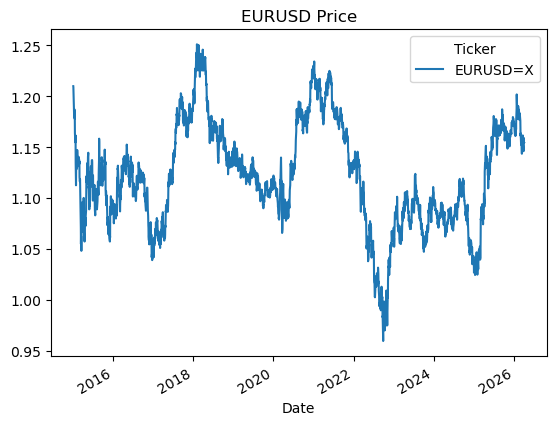

In [37]:
#DATA COLLECTION FX DATA (Market)
import yfinance as yf
import matplotlib.pyplot as plt

# Correct Forex tickers
eurusd = yf.download("EURUSD=X", start="2015-01-01")
gbpusd = yf.download("GBPUSD=X", start="2015-01-01")

# Check data
print(eurusd.head())

# Plot
eurusd['Close'].plot(title="EURUSD Price")
plt.show()

In [41]:
#Price Chart
import matplotlib.pyplot as plt

data.plot(title="FX Price Trends (EURUSD & GBPUSD)")
plt.savefig("outputs/charts/fx_price_trends.png")
plt.close()

In [42]:
#Returns Charts
returns.plot(title="FX Returns Over Time")
plt.savefig("outputs/charts/fx_returns.png")
plt.close()

In [43]:
#Volatility Chart
volatility.plot(title="FX Volatility (30-Day Rolling)")
plt.savefig("outputs/charts/fx_volatility.png")
plt.close()

In [44]:
#Correlation Heatmap
import seaborn as sns

corr = merged[['EURUSD','GBPUSD','US_Rate','NG_Rate']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.savefig("outputs/charts/correlation_matrix.png")
plt.close()

In [45]:
#Scatter Plot (Macro Relationship)
plt.scatter(merged['US_Rate'], merged['EURUSD'])
plt.xlabel("US Interest Rate")
plt.ylabel("EURUSD")
plt.title("EURUSD vs US Interest Rate")
plt.savefig("outputs/charts/eurusd_vs_rates.png")
plt.close()

In [8]:
import yfinance as yf

pairs = ["EURUSD=X", "GBPUSD=X"]

data = yf.download(pairs, start="2015-01-01")['Close']

[*********************100%***********************]  2 of 2 completed


In [34]:
#Data Cleaning
data = data.dropna()

In [33]:
#RETURNS ENGINEERING
returns = data.pct_change().dropna()

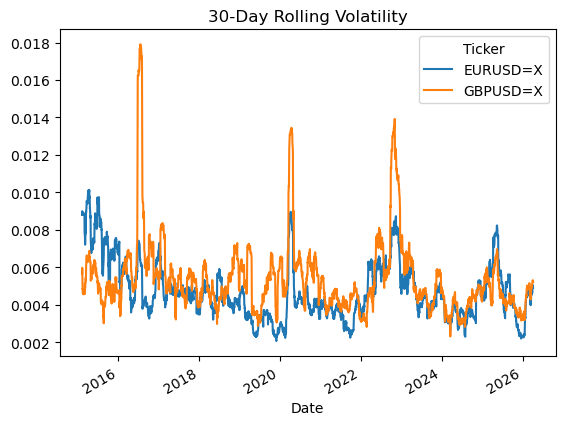

In [36]:
#Volatility Analysis
volatility = returns.rolling(30).std()

volatility.plot(title="30-Day Rolling Volatility");

In [12]:
returns.corr()

Ticker,EURUSD=X,GBPUSD=X
Ticker,,
EURUSD=X,1.00000,0.62297
GBPUSD=X,0.62297,1.00000


In [15]:
import pandas as pd

In [17]:
macro_data = pd.DataFrame({
    "Date": ["2015","2016","2017","2018","2019","2020","2021","2022","2023","2024"],
    "US_Rate": [0.25,0.50,1.00,1.50,2.50,0.25,0.25,2.50,5.00,5.50],
    "NG_Rate": [13.0,14.0,14.0,14.0,13.5,12.5,11.5,16.5,18.75,24.75]
})

In [18]:
returns['Year'] = returns.index.year
yearly_returns = returns.groupby('Year').mean().reset_index()

In [20]:
macro_data.rename(columns={'Date': 'Year'}, inplace=True)
macro_data['Year'] = macro_data['Year'].astype(int)

merged = yearly_returns.merge(macro_data, on='Year')
#merged = yearly_returns.merge(macro_data, left_on='Year', right_on='Date')

In [32]:
#CORRELATION ANALYSIS
corr_matrix = merged[['EURUSD', 'GBPUSD', 'US_Rate', 'NG_Rate']].corr()
print(corr_matrix)

           EURUSD    GBPUSD   US_Rate   NG_Rate
EURUSD   1.000000  0.631434 -0.043212 -0.105811
GBPUSD   0.631434  1.000000  0.207068  0.024539
US_Rate -0.043212  0.207068  1.000000  0.906626
NG_Rate -0.105811  0.024539  0.906626  1.000000


In [24]:
merged.rename(columns={
    'EURUSD=X': 'EURUSD',
    'GBPUSD=X': 'GBPUSD'
}, inplace=True)

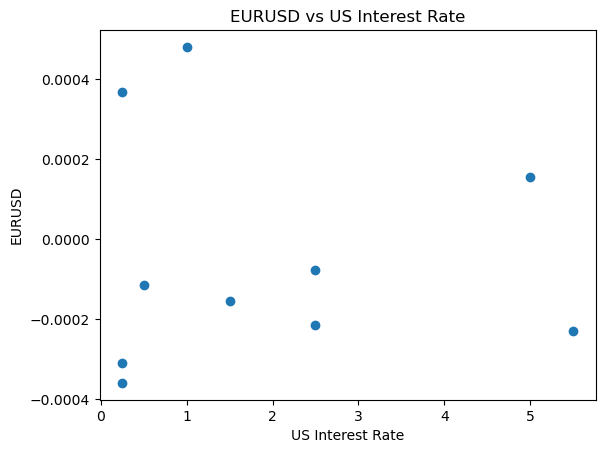

In [31]:
#VISUAL RELATIONSHIP
import matplotlib.pyplot as plt

plt.scatter(merged['US_Rate'], merged['EURUSD'])
plt.xlabel("US Interest Rate")
plt.ylabel("EURUSD")
plt.title("EURUSD vs US Interest Rate")
plt.show()

In [27]:
import statsmodels.api as sm

X = merged['US_Rate']
y = merged['EURUSD']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 EURUSD   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.123
Method:                 Least Squares   F-statistic:                   0.01497
Date:                Mon, 06 Apr 2026   Prob (F-statistic):              0.906
Time:                        16:27:37   Log-Likelihood:                 67.938
No. Observations:                  10   AIC:                            -131.9
Df Residuals:                       8   BIC:                            -131.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.291e-05      0.000     -0.238      0.8

C:\Users\THIS PC\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


In [28]:
#Merge
merged['EURUSD_vol'] = merged['EURUSD'].rolling(2).std()

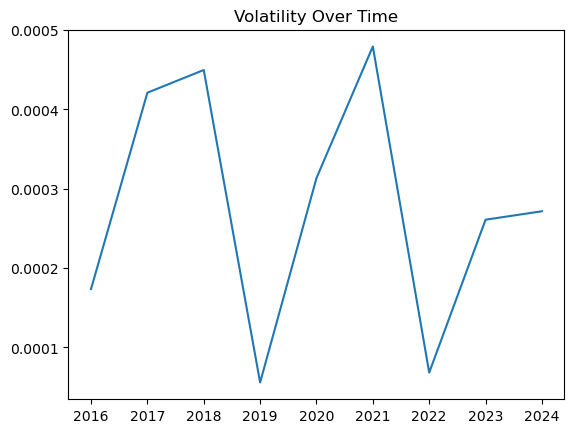

In [30]:
#VOLATILITY VS POLICY
plt.plot(merged['Year'], merged['EURUSD_vol'])
plt.title("Volatility Over Time")
plt.show()